In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-detuning-filter',
        '--data_dir', '../../data/kalman',
        '--data_file', 'tesla_sim',
        '--data_nsample', '500',
        '--data_train_size', '0.8',
        '--data_test_size', '0.5',
        '--target_ndim', '1',

        '--feature_dim', '0,1',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '100',
        '--patience', '10',
        '--checkpoints', '../../models/kalman/filter',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 3, "cos": 3}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '64',
        '--nlayer_stat', '2',
        '--nneuron_trans', '128',
        '--nlayer_trans', '3',
    ]
)

In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.839869, valid=0.195396, test=0.185789
	validation loss decreased (inf -> 0.195396), saving model ...
	epoch 2 losses: train=1.001983, valid=0.074368, test=0.068336
	validation loss decreased (0.195396 -> 0.074368), saving model ...
	epoch 3 losses: train=0.688998, valid=0.066561, test=0.060736
	validation loss decreased (0.074368 -> 0.066561), saving model ...
	epoch 4 losses: train=0.663648, valid=0.063451, test=0.057663
	validation loss decreased (0.066561 -> 0.063451), saving model ...
	epoch 5 losses: train=0.652506, valid=0.062641, test=0.057063
	validation loss decreased (0.063451 -> 0.062641), saving model ...
	epoch 6 losses: train=0.639766, valid=0.062014, test=0.056991
	validation loss decreased (0.062641 -> 0.062014), saving model ...
	epoch 7 losses: train=0.573745, valid=0.055119, test=0.052092
	validation loss decreased (0.062014 -> 0.055119), saving model ...
	epoch 8 losses: train=0.301846, valid=0.026348, test=0.02

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

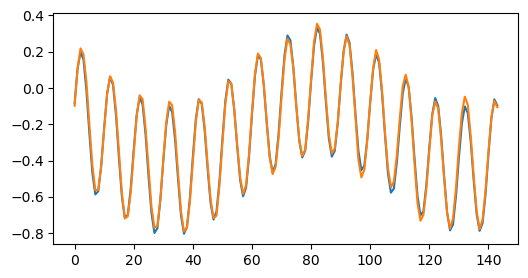

In [6]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break